In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("All packages loaded successfully!")

All packages loaded successfully!


In [4]:
import numpy as np
print("numpy ok")

numpy ok


In [5]:
import matplotlib.pyplot as plt
print("matplotlib ok")

matplotlib ok


In [6]:
import seaborn as sns
print("seaborn ok")


seaborn ok


In [7]:
import tensorflow as tf
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [8]:
from tensorflow.keras import datasets
from tensorflow.keras.utils import to_categorical

(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 27s 0us/step
Training Images: (50000, 32, 32, 3)
Testing Images: (10000, 32, 32, 3)


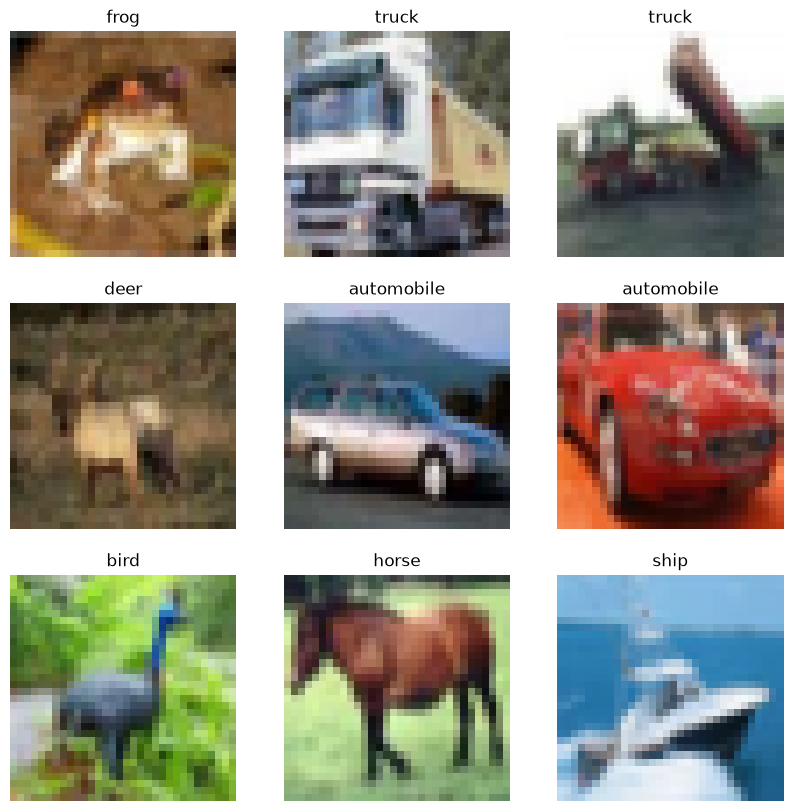

In [9]:
import matplotlib.pyplot as plt

class_names = [
    'airplane','automobile','bird','cat','deer',
    'dog','frog','horse','ship','truck'
]

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.show()

In [10]:
from tensorflow.keras import models, layers

ann_model = models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

/opt/anaconda3/envs/celebal/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history_ann = ann_model.fit(
    X_train,
    y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3267 - loss: 1.8857 - val_accuracy: 0.3619 - val_loss: 1.7657
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3984 - loss: 1.6799 - val_accuracy: 0.4014 - val_loss: 1.6894
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.4254 - loss: 1.6024 - val_accuracy: 0.4291 - val_loss: 1.5947
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4467 - loss: 1.5420 - val_accuracy: 0.4463 - val_loss: 1.5655
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.4681 - loss: 1.4933 - val_accuracy: 0.4618 - val_loss: 1.5390
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4739 - loss: 1.4711 - val_accuracy: 0.4709 - val_loss: 1.5033
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4873 - loss: 1.4341 - val_accuracy: 0.4711 - val_loss: 1.5018
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4978 - loss: 1.4079 - val_accuracy: 0.

In [12]:
ann_loss, ann_acc = ann_model.evaluate(
    X_test,
    y_test_cat
)

print("ANN Test Accuracy:", ann_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4767 - loss: 1.4898
ANN Test Accuracy: 0.4767000079154968


In [13]:
from tensorflow.keras import models, layers

cnn_model = models.Sequential([

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    layers.Flatten(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dense(
        10,
        activation='softmax'
    )

])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/opt/anaconda3/envs/celebal/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history_cnn = cnn_model.fit(
    X_train,
    y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.4054 - loss: 1.6302 - val_accuracy: 0.4895 - val_loss: 1.4354
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.5474 - loss: 1.2641 - val_accuracy: 0.5906 - val_loss: 1.1626
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.6085 - loss: 1.1030 - val_accuracy: 0.6224 - val_loss: 1.0708
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.6504 - loss: 0.9918 - val_accuracy: 0.6521 - val_loss: 0.9995
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.6783 - loss: 0.9122 - val_accuracy: 0.6675 - val_loss: 0.9585
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.7074 - loss: 0.8363 - val_accuracy: 0.6855 - val_loss: 0.9141
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.7313 - loss: 0.7678 - val_accuracy: 0.6836 - val_loss: 0.9201
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.7524 - loss: 0.7093 - 

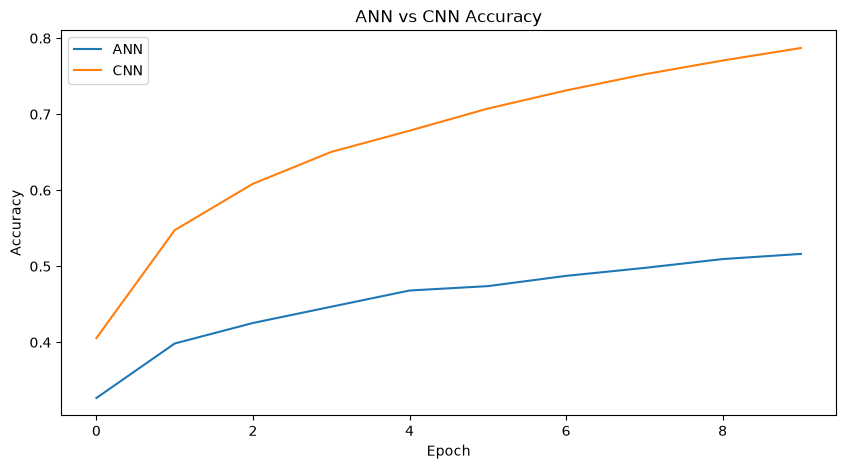

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    history_ann.history['accuracy'],
    label='ANN'
)

plt.plot(
    history_cnn.history['accuracy'],
    label='CNN'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('ANN vs CNN Accuracy')
plt.legend()
plt.show()

In [16]:
ann_loss, ann_acc = ann_model.evaluate(X_test, y_test_cat)

print("ANN Test Accuracy:", ann_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4767 - loss: 1.4898
ANN Test Accuracy: 0.4767000079154968


In [17]:
from tensorflow.keras import models, layers

cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history_cnn = cnn_model.fit(
    X_train,
    y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.4333 - loss: 1.5492 - val_accuracy: 0.5234 - val_loss: 1.3255
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.5770 - loss: 1.1882 - val_accuracy: 0.6025 - val_loss: 1.1276
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.6379 - loss: 1.0257 - val_accuracy: 0.6349 - val_loss: 1.0497
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.6805 - loss: 0.9094 - val_accuracy: 0.6573 - val_loss: 0.9874
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.7147 - loss: 0.8125 - val_accuracy: 0.6737 - val_loss: 0.9451
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.7416 - loss: 0.7367 - val_accuracy: 0.7101 - val_loss: 0.8417
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.7643 - loss: 0.6696 - val_accuracy: 0.6822 - val_loss: 0.9187
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.7864 - loss: 0.6075 - 

In [19]:
cnn_loss, cnn_acc = cnn_model.evaluate(X_test, y_test_cat)

print("CNN Test Accuracy:", cnn_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7144 - loss: 0.9030
CNN Test Accuracy: 0.7143999934196472


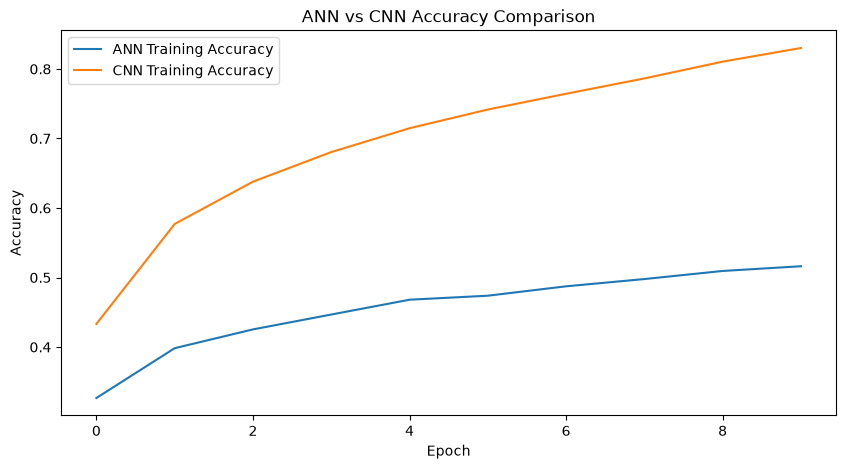

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history_ann.history['accuracy'],
         label='ANN Training Accuracy')

plt.plot(history_cnn.history['accuracy'],
         label='CNN Training Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('ANN vs CNN Accuracy Comparison')
plt.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


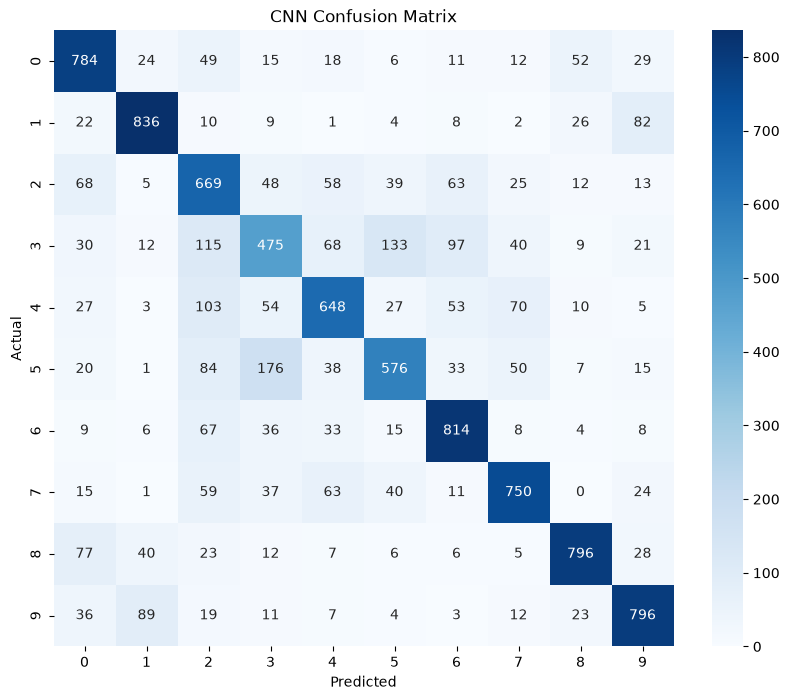

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

predictions = cnn_model.predict(X_test)

pred_classes = np.argmax(predictions, axis=1)

cm = confusion_matrix(
    y_test.flatten(),
    pred_classes
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('CNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()